# first import all necessary libraries

In [ ]:
# import libraries
import numpy as np                  # For numerical operations and array handling
import pandas as pd                 # For data loading and manipulation (working with CSVs)
import matplotlib.pyplot as plt     # For basic data visualization
import seaborn as sb                # For advanced statistical data visualization

from sklearn.preprocessing import StandardScaler, LabelEncoder # For scaling data and encoding categories
# KMeans → K-Means clustering algorithm
from sklearn.cluster import KMeans  # For the K-Means clustering algorithm

import warnings                     # To manage or ignore system warning messages
warnings.filterwarnings('ignore')   # Suppress warnings to keep the output clean

## load the dataset

In [ ]:
# loading the dataset from the csv file
df=pd.read_csv('customer_segmentation_data.csv')

In [ ]:
# Display the first 5 rows to verify the data
print(df.head())


     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

In [ ]:
# to check the shape of the data
df.shape


(2240, 29)

## Data Preprocessing & Cleaning

In [ ]:
# 1 to see the structure and check for missing values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [ ]:
## to check the null value of dataset
for col in df.columns:
    temp = df[col].isnull().sum()
    if temp > 0:
        print(f'Column {col} contains {temp} null values.')

Column Income contains 24 null values.


In [ ]:
# once we have the count of the null values and we know the values are very less
#  we can drop them as it will not affect the dataset much.

df = df.dropna()
print("Total values in the dataset after removing the null values:", len(df))

Total values in the dataset after removing the null values: 2216


#### Date Conversion & Tenure Extraction

In [ ]:
# 1. Convert Dt_Customer to datetime objects
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

# 2. Extract 'Tenure' (Number of days since they joined until now - April 2026)
current_date = pd.to_datetime('2026-04-18')
df['Tenure'] = (current_date - df['Dt_Customer']).dt.days

# Check the results
print(df[['Dt_Customer', 'Tenure']].sample(10))

     Dt_Customer  Tenure
1747  2013-09-28    4585
1642  2012-10-27    4921
109   2012-12-07    4880
1039  2013-05-29    4707
2139  2012-08-06    5003
1618  2014-01-27    4464
1761  2013-03-10    4787
1930  2013-11-20    4532
7     2013-05-08    4728
1735  2013-02-18    4807


## Feature Engineering


Feature engineering is the process of using domain knowledge to transform, extract, or create new variables (columns) from your raw data to make your machine learning models perform better.


#### Creating New Features (Age, Total_Spend, Family_Size)

In [ ]:
# 1. Calculate the customer's age (assuming current year is 2026)
df['Age'] = 2026 - df['Year_Birth']

In [ ]:
# 2. Calculate total spending (summing all columns that start with 'Mnt')
mnt_cols = [col for col in df.columns if 'Mnt' in col]
df['Total_Spend'] = df[mnt_cols].sum(axis=1) # to add each customers horizontally

In [ ]:
# 3. Calculate family size (summing kids + teens + 1 for the adult)
df['Family_Size'] = df['Kidhome'] + df['Teenhome'] + 1

In [ ]:
# Display the newly created features to verify
print(df[['Age', 'Total_Spend', 'Family_Size']].head())

   Age  Total_Spend  Family_Size
0   69         1617            1
1   72           27            3
2   61          776            1
3   42           53            2
4   45          422            2


## Exploratory Data Analysis (EDA)

it's the process of analyzing data sets to summarize their main characteristics, often with visual methods. It's used to discover patterns, spot anomalies, test hypotheses, and check assumptions with the help of statistical graphics and other data visualization methods.

Univariate Analysis: Check the distribution of age, income, and spending scores (use seaborn histograms/boxplots).

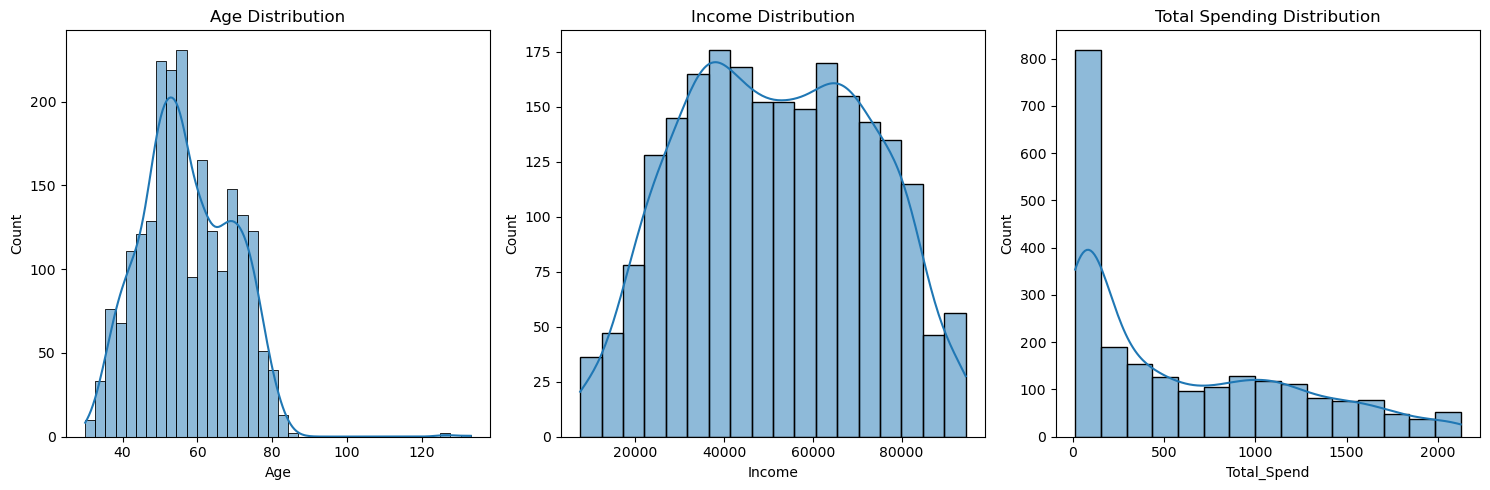

In [ ]:
# Univariate Analysis (Histograms)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1) #The third number (1 ) is index (the position of the current subplot within that grid, starting from 1).
sns.histplot(df['Age'], kde=True) # kde=True to add a smooth countinuous line on the top of chart
plt.title('Age Distribution')
plt.subplot(1, 3, 2)
sns.histplot(df['Income'], kde=True)
plt.title('Income Distribution')
plt.subplot(1, 3, 3)
sns.histplot(df['Total_Spend'], kde=True)
plt.title('Total Spending Distribution')
plt.tight_layout()
plt.savefig('univariate_analysis.png')

#### Correlation Heatmap

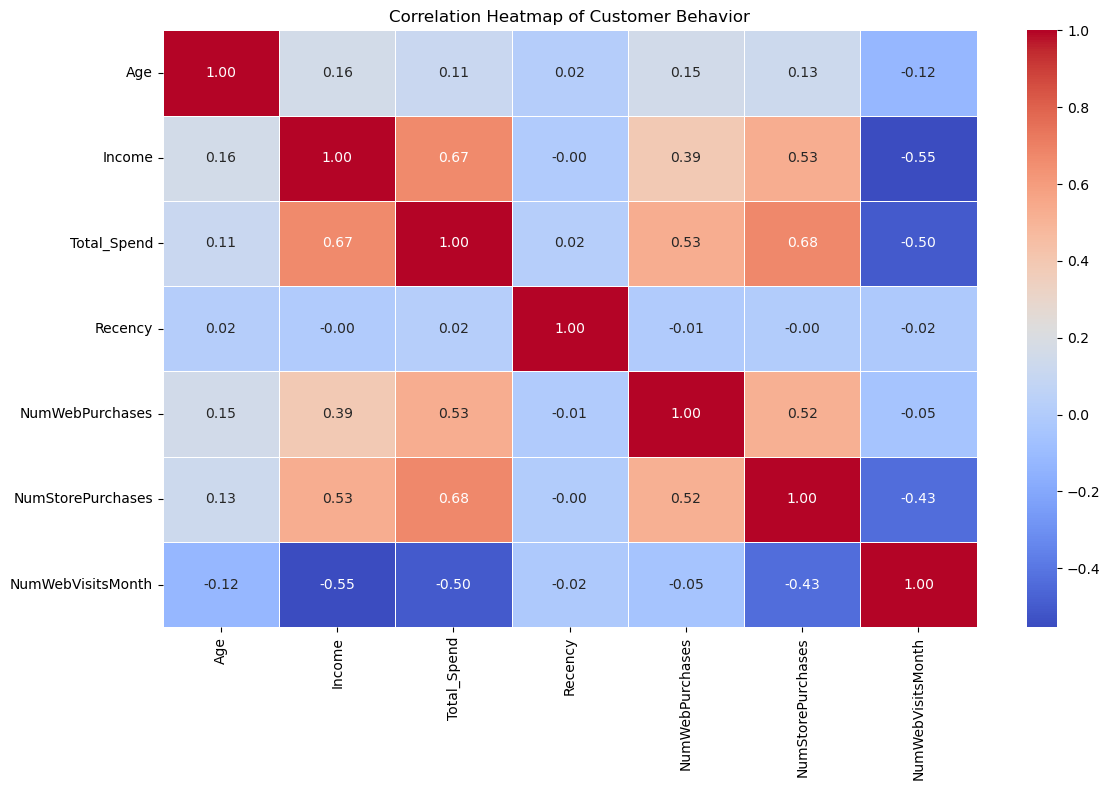

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select the relevant numerical columns for analysis
# We exclude non-numeric columns like 'Education' or 'Marital_Status'
# because correlation only works with numbers.
cols_to_analyze = ['Age', 'Income', 'Total_Spend', 'Recency',
                   'NumWebPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

# 2. Calculate the correlation matrix
correlation_matrix = df[cols_to_analyze].corr()

# 3. Create the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Customer Behavior')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

#### Outlier Detection

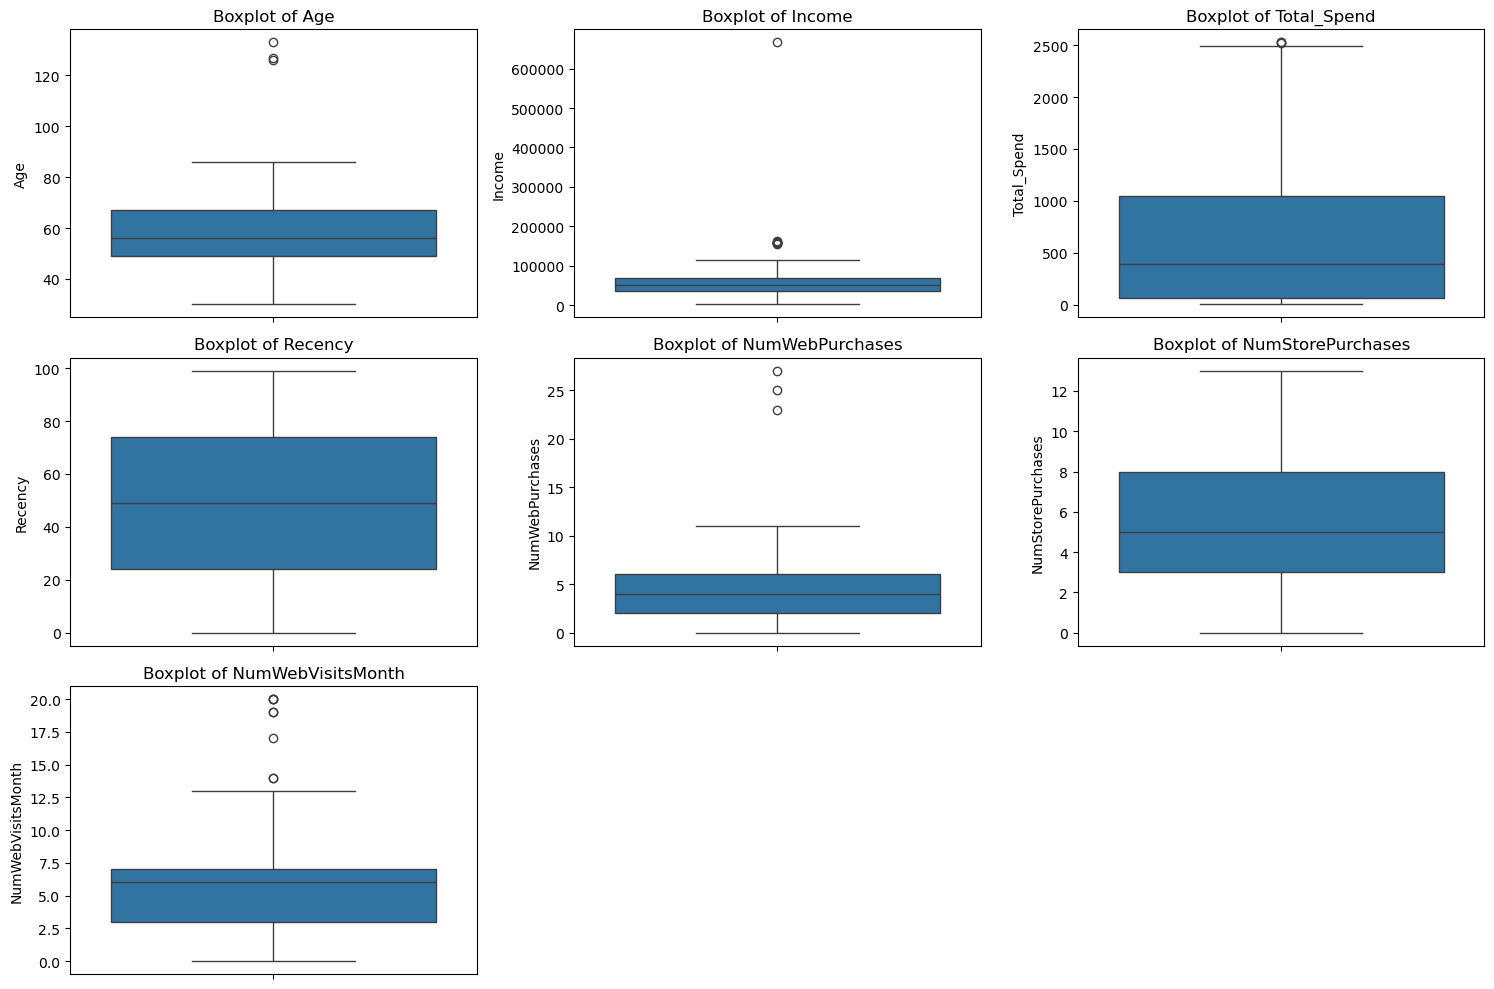

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# Features for boxplot
features = ['Age', 'Income', 'Total_Spend', 'Recency', 'NumWebPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

# Create boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.savefig('outlier_detection_all.png')
plt.show()

A common professional technique to handle outliers without deleting data is Winsorization (Capping). Instead of deleting the extreme rows, we cap the values at a certain percentile (e.g., 1st and 99th percentile)

In [ ]:
# Function to cap outliers using the 1st and 99th percentile
def cap_outliers(df, column):
    lower_limit = df[column].quantile(0.01)
    upper_limit = df[column].quantile(0.99)
    df[column] = df[column].clip(lower=lower_limit, upper=upper_limit)
    return df

# Apply capping to critical columns
df = cap_outliers(df, 'Income')
df = cap_outliers(df, 'Total_Spend')
df = cap_outliers(df, 'Age')

print("Outliers capped for Income ,Age and  Total_Spend.")

Outliers capped for Income and Total_Spend.


#### Feature Selection

In [ ]:
# 1. Define the relevant features
# We select numerical columns that directly influence buying behavior
relevant_features = [
    'Income', 'Age', 'Total_Spend', 'Recency',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth', 'NumDealsPurchases', 'Kidhome', 'Teenhome'
]

# 2. Subset the dataframe
# We create a new clean dataframe containing only the selected features
df_selected = df[relevant_features].copy()

# 3. Check the shape to see how many columns we kept
print(f"Original shape: {df.shape}")
print(f"New shape after selection: {df_selected.shape}")

# Inspect the head of the new selection
print(df_selected.head())

Original shape: (2216, 33)
New shape after selection: (2216, 11)
    Income  Age  Total_Spend  Recency  NumWebPurchases  NumCatalogPurchases  \
0  58138.0   69         1617       58                8                   10   
1  46344.0   72           27       38                1                    1   
2  71613.0   61          776       26                8                    2   
3  26646.0   42           53       26                2                    0   
4  58293.0   45          422       94                5                    3   

   NumStorePurchases  NumWebVisitsMonth  NumDealsPurchases  Kidhome  Teenhome  
0                  4                  7                  3        0         0  
1                  2                  5                  2        1         1  
2                 10                  4                  1        0         0  
3                  4                  6                  2        1         0  
4                  6                  5                  5  

#### Binary Encoding

In [ ]:
# 1. Select the categorical columns
categorical_cols = ['Education', 'Marital_Status']

# 2. Apply One-Hot Encoding
# pd.get_dummies creates new columns for each category (e.g., Education_Graduation, Education_PhD)
df_encoded = pd.get_dummies(df[categorical_cols], prefix=categorical_cols)

# 3. Join the encoded columns back to your numerical features
# Assuming 'df_selected' contains your numerical features from the previous step
# We join the new one-hot encoded columns to the numerical ones
df_final = pd.concat([df_selected, df_encoded], axis=1)

print("Encoding complete. New shape with encoded columns:")
print(df_final.shape)
print(df_final.head())

Encoding complete. New shape with encoded columns:
(2216, 24)
    Income  Age  Total_Spend  Recency  NumWebPurchases  NumCatalogPurchases  \
0  58138.0   69         1617       58                8                   10   
1  46344.0   72           27       38                1                    1   
2  71613.0   61          776       26                8                    2   
3  26646.0   42           53       26                2                    0   
4  58293.0   45          422       94                5                    3   

   NumStorePurchases  NumWebVisitsMonth  NumDealsPurchases  Kidhome  ...  \
0                  4                  7                  3        0  ...   
1                  2                  5                  2        1  ...   
2                 10                  4                  1        0  ...   
3                  4                  6                  2        1  ...   
4                  6                  5                  5        1  ...   

   Edu

#### Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the StandardScaler
scaler = StandardScaler()

# 2. Fit and transform the data
# We apply this to df_selected (which we created in the previous step)
scaled_data = scaler.fit_transform(df_selected)

# 3. Convert the result back to a DataFrame
# The scaler returns a NumPy array, so we convert it back to a DataFrame
# so we can keep the column names.
df_scaled = pd.DataFrame(scaled_data, columns=df_selected.columns)

# 4. Check the results
print("Scaling complete. Here is the first 5 rows of the scaled data:")
print(df_scaled.head())

Scaling complete. Here is the first 5 rows of the scaled data:
     Income       Age  Total_Spend   Recency  NumWebPurchases  \
0  0.307263  0.986443     1.692256  0.310532         1.428553   
1 -0.261835  1.236801    -0.967385 -0.380509        -1.125881   
2  0.957474  0.318822     0.285490 -0.795134         1.428553   
3 -1.212326 -1.266777    -0.923894 -0.795134        -0.760962   
4  0.314742 -1.016420    -0.306656  1.554407         0.333796   

   NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  \
0             2.504712          -0.554143           0.693232   
1            -0.571082          -1.169518          -0.131574   
2            -0.229327           1.291982          -0.543978   
3            -0.912837          -0.554143           0.280829   
4             0.112428           0.061232          -0.131574   

   NumDealsPurchases   Kidhome  Teenhome  
0           0.351713 -0.823039 -0.928972  
1          -0.168231  1.039938  0.909066  
2          -0.688176 -0.823039 -

Encoding complete. New shape with encoded columns:
(2216, 24)
    Income  Age  Total_Spend  Recency  NumWebPurchases  NumCatalogPurchases  \
0  58138.0   69         1617       58                8                   10   
1  46344.0   72           27       38                1                    1   
2  71613.0   61          776       26                8                    2   
3  26646.0   42           53       26                2                    0   
4  58293.0   45          422       94                5                    3   

   NumStorePurchases  NumWebVisitsMonth  NumDealsPurchases  Kidhome  ...  \
0                  4                  7                  3        0  ...   
1                  2                  5                  2        1  ...   
2                 10                  4                  1        0  ...   
3                  4                  6                  2        1  ...   
4                  6                  5                  5        1  ...   

   Edu

#### Dimentionality Reduction(PCA)

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

# 1. Initialize PCA
# We start with n_components=2 for easy 2D visualization
pca = PCA(n_components=2)

# 2. Fit and transform your scaled data
# Use the 'scaled_data' variable from your previous step
pca_data = pca.fit_transform(scaled_data)

# 3. Create a DataFrame to view the Principal Components (PC1 and PC2)
df_pca = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])

print("PCA Transformation Complete.")
print(df_pca.head())

# 4. (Optional but Recommended) Check Explained Variance
# This tells you how much information is kept.
explained_variance = pca.explained_variance_ratio_
print(f"\nExplained Variance Ratio: {explained_variance}")
print(f"Total Variance retained: {sum(explained_variance) * 100:.2f}%")

PCA Transformation Complete.
        PC1       PC2
0  2.221448  0.414060
1 -1.695296  0.348431
2  1.883102 -0.377164
3 -2.305554 -1.171952
4 -0.327657  0.069708

Explained Variance Ratio: [0.39292827 0.16135754]
Total Variance retained: 55.43%


## Model Training

### The Elbow Method

The Elbow Method helps you determine the optimal number of clusters by plotting the model's error (inertia) against an increasing number of groups. You identify the "elbow" point on the graph where the sharp decline in error levels off, signaling that adding more clusters provides diminishing benefits. This allows you to choose a balance where your data segments are meaningful and distinct without making the model unnecessarily complex.

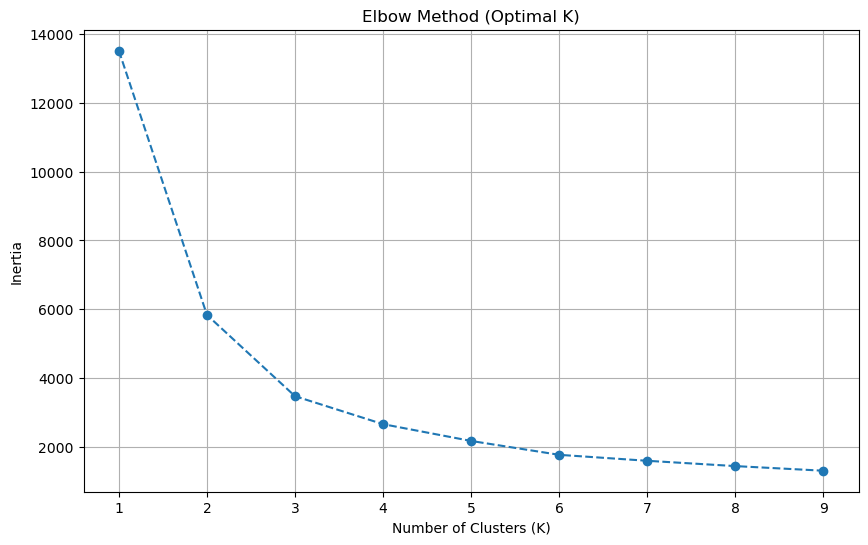

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Store the inertia values for each K
inertia = []
K_range = range(1, 10) # Checking for 1 to 9 clusters

# 2. Loop to calculate inertia for each K
for k in K_range:
    # We use df_pca as the input
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(df_pca)
    inertia.append(kmeans.inertia_)

# 3. Plot the Elbow graph
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method (Optimal K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [ ]:
# 1. Initialize KMeans with the optimal K = 3
final_kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)

# 2. Fit and predict on your PCA data
df_pca['Cluster'] = final_kmeans.fit_predict(df_pca)

print("Clustering completed with 3 clusters!")
print(df_pca.head())

Clustering completed with 3 clusters!
        PC1       PC2  Cluster
0  2.221448  0.414060        1
1 -1.695296  0.348431        0
2  1.883102 -0.377164        1
3 -2.305554 -1.171952        0
4 -0.327657  0.069708        0


In [ ]:
import joblib

# Save the trained KMeans model
joblib.dump(final_kmeans, 'Kmeans_Model.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

print('Models saved successfully!')

#### Cluster Profiling

In [ ]:
# 1. First, add the 'Cluster' labels back to your original DataFrame
df['Cluster'] = df_pca['Cluster'].astype(int)

# 2. Calculate the average of the most important columns
# This helps you define the "Persona" of each cluster by looking at the mean values
cluster_analysis = df.groupby('Cluster')[['Income', 'Total_Spend', 'Age']].mean()

# 3. Optional: Check the number of customers in each cluster
# This ensures that you don't have a cluster with too few people
cluster_count = df.groupby('Cluster')['Cluster'].count()

# Display the results
print("--- Cluster Averages ---")
print(cluster_analysis)
print("\n--- Number of customers in each cluster ---")
print(cluster_count)

--- Cluster Averages ---
               Income  Total_Spend        Age
Cluster                                      
0.0      51390.912590   601.930399  57.415558
1.0      51594.219723   587.581315  57.583045
2.0      52611.378370   630.476489  56.547022

--- Number of customers in each cluster ---
Cluster
0.0    977
1.0    578
2.0    638
Name: Cluster, dtype: int64


### Silhouette Score Implementation

The Silhouette Score is a metric that measures how well-separated your clusters are. While the Elbow Method tells you where the "cost" drops, the Silhouette Score tells you the "quality" of the separation.

In [ ]:
from sklearn.metrics import silhouette_score

# Calculate the silhouette score
# We use df_pca (our reduced data) and the cluster labels generated by final_kmeans
score = silhouette_score(df_pca, final_kmeans.labels_)

print(f"The Silhouette Score for 3 clusters is: {score:.4f}")


# Interpretation:
# A score between 0.2 and 0.5 is generally good for complex real-world data like customer segmentation.

The Silhouette Score for 3 clusters is: 0.5562


#### Visualization (Scatter Plot)

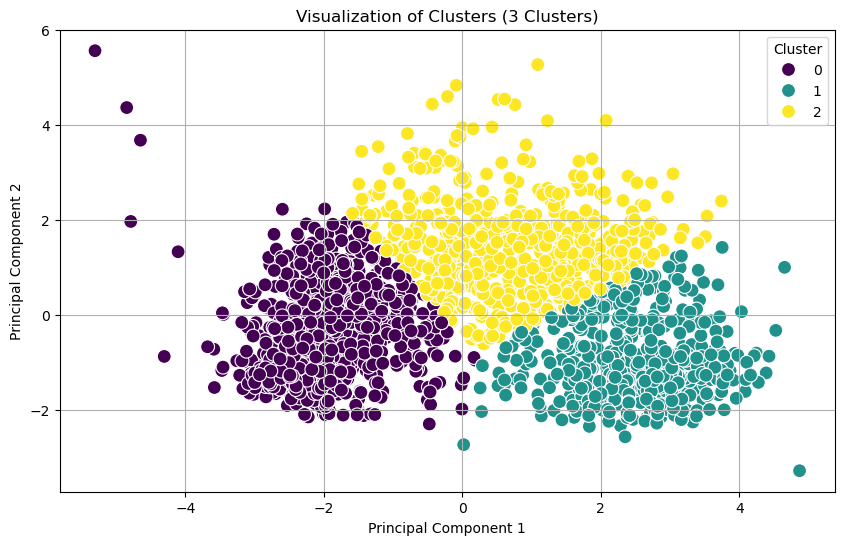

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the plot size
plt.figure(figsize=(10, 6))

# Create the scatter plot
# We use 'hue' to color the points based on their assigned cluster
sns.scatterplot(x='PC1', y='PC2', hue=final_kmeans.labels_, data=df_pca, palette='viridis', s=100)

# Add titles and labels for clarity
plt.title('Visualization of Clusters (3 Clusters)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

### Business Insight/Profiling

#### step 1: mapping

In [ ]:
# 1. Map the Cluster numbers to Descriptive Names
# Cluster 0 -> Steady Consumers, Cluster 1 -> Cautious Spenders, Cluster 2 -> High-Value Spenders
cluster_mapping = {
    0: 'Steady Consumers',
    1: 'Cautious Spenders',
    2: 'High-Value Spenders'
}

# Create a new column with the names
df['Cluster_Name'] = df['Cluster'].map(cluster_mapping)

print("Mapping complete! New column 'Cluster_Name' added.")

Mapping complete! New column 'Cluster_Name' added.


#### step 2: Analysis with Names

In [ ]:
# 2. Group by the new descriptive names
# This is much easier to read in a report
insight_table = df.groupby('Cluster_Name')[['Income', 'Total_Spend', 'Age']].mean()

# Display the professional table
print(insight_table)

                           Income  Total_Spend        Age
Cluster_Name                                             
Cautious Spenders    51594.219723   587.581315  57.583045
High-Value Spenders  52611.378370   630.476489  56.547022
Steady Consumers     51390.912590   601.930399  57.415558


### Business Report

#### Barchart

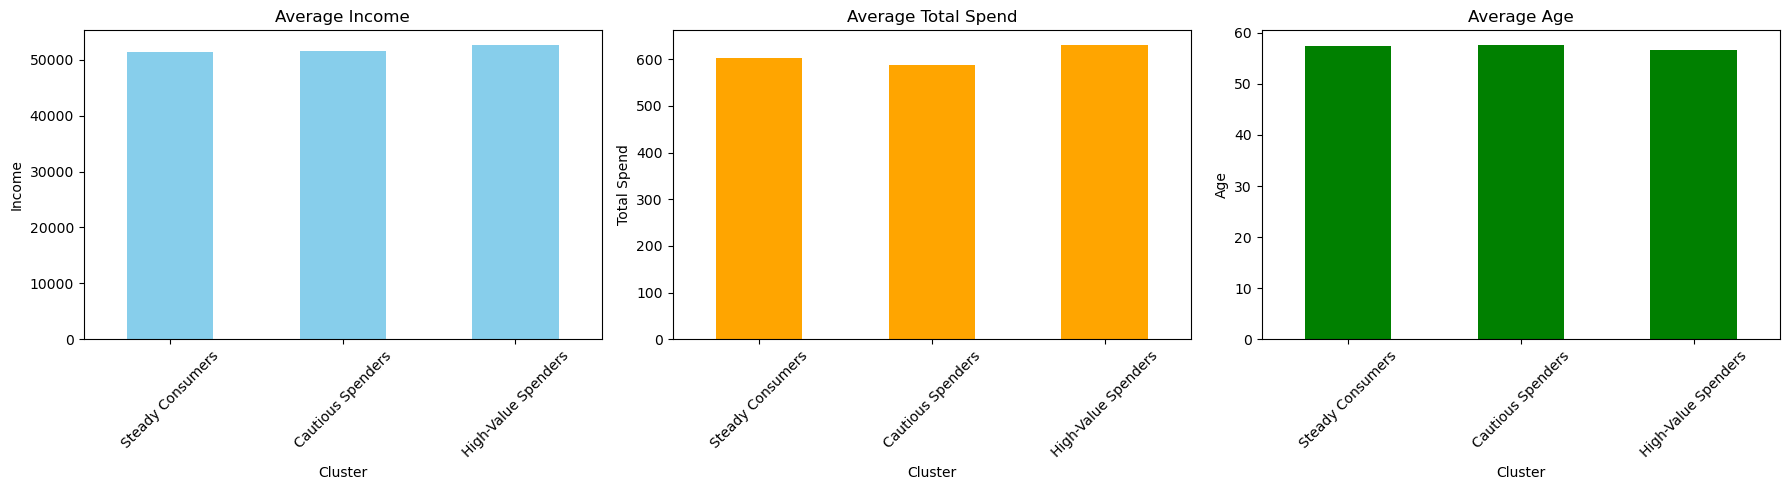

In [ ]:
import matplotlib.pyplot as plt

# 1. Map the cluster numbers to descriptive persona names
# This makes your final charts understandable to stakeholders
cluster_names = {
    0.0: 'Steady Consumers',
    1.0: 'Cautious Spenders',
    2.0: 'High-Value Spenders'
}

# 2. Rename the index of your analysis table using the mapping above
df_renamed = cluster_analysis.rename(index=cluster_names)

# 3. Create visualizations in 3 side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Average Income
df_renamed['Income'].plot(kind='bar', ax=axes[0], color='skyblue', title='Average Income')
axes[0].set_ylabel('Income')
axes[0].tick_params(axis='x', rotation=45)

# Plot Average Total Spend
df_renamed['Total_Spend'].plot(kind='bar', ax=axes[1], color='orange', title='Average Total Spend')
axes[1].set_ylabel('Total Spend')
axes[1].tick_params(axis='x', rotation=45)

# Plot Average Age
df_renamed['Age'].plot(kind='bar', ax=axes[2], color='green', title='Average Age')
axes[2].set_ylabel('Age')
axes[2].tick_params(axis='x', rotation=45)

# 4. Final layout adjustments
plt.tight_layout()
plt.show()